In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

import inversion_tools

In [9]:
# ------ first read 
pdir = '/work/noaa/co2/jhollo/processed_transport_data/' 
data_r14 = inversion_tools.read_transport_jacobians_residual('ocean', '2014-09-01', '2019-01-01', 
                                                             region=14, month='2016-01',
                                                             return_mf=True, return_flux=False, processing_dir=pdir, quiet=True)

reading data for splits [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
---------- split 1 ----------
reading mole fraction data for all vertical levels...
took 6.20 s
done
---------- split 2 ----------
reading mole fraction data for all vertical levels...
took 8.33 s
done
---------- split 3 ----------
reading mole fraction data for all vertical levels...
took 8.36 s
done
---------- split 4 ----------
reading mole fraction data for all vertical levels...
took 9.44 s
done
---------- split 5 ----------
reading mole fraction data for all vertical levels...
took 8.66 s
done
---------- split 6 ----------
reading mole fraction data for all vertical levels...
took 9.92 s
done
---------- split 7 ----------
reading mole fraction data for all vertical levels...
took 8.48 s
done
---------- split 8 ----------
reading mole fraction data for all vertical levels...
took 9.14 s
done
---------- split 9 ----------
reading mole fraction data for all vertical levels...
took 9.45 s
done
---------- split 10 ------

In [21]:
dd14 = data_r14['residual'].mean('lon').isel(lev=35).isel(time=slice(0, 900))
dd13 = data_r13['residual'].mean('lon').isel(lev=35).isel(time=slice(0, 900))

In [26]:
dd14_slice = data_r14['residual'].mean('lon')

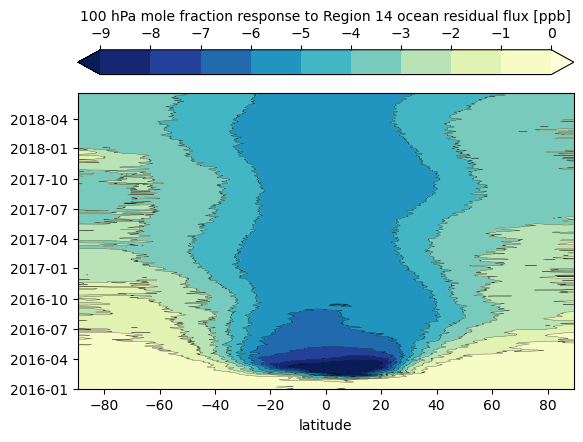

In [22]:
# lat-time at 100 hPa
dd = dd14
levels = [-9, -8, -7, -6, -5, -4, -3, -2, -1, 0]
fig = plt.figure()
ax = fig.add_subplot()
cf = ax.contourf(dd.lat, dd.time, dd*1e3, levels=levels, extend='both', cmap='YlGnBu_r')
ax.contour(dd.lat, dd.time, dd*1e3, levels=levels, colors='k', linestyles='-', linewidths=0.2)
ax.set_xlabel('latitude')
cb = plt.colorbar(cf, location='top')
cb.set_label('100 hPa mole fraction response to Region 14 ocean residual flux [ppb]')

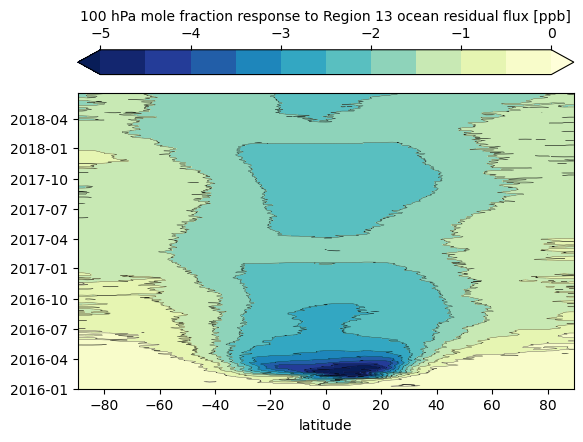

In [23]:
# lat-time at 100 hPa
dd = dd13
levels = [-5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0]
fig = plt.figure()
ax = fig.add_subplot()
cf = ax.contourf(dd.lat, dd.time, dd*1e3, levels=levels, extend='both', cmap='YlGnBu_r')
ax.contour(dd.lat, dd.time, dd*1e3, levels=levels, colors='k', linestyles='-', linewidths=0.2)
ax.set_xlabel('latitude')
cb = plt.colorbar(cf, location='top')
cb.set_label('100 hPa mole fraction response to Region 13 ocean residual flux [ppb]')

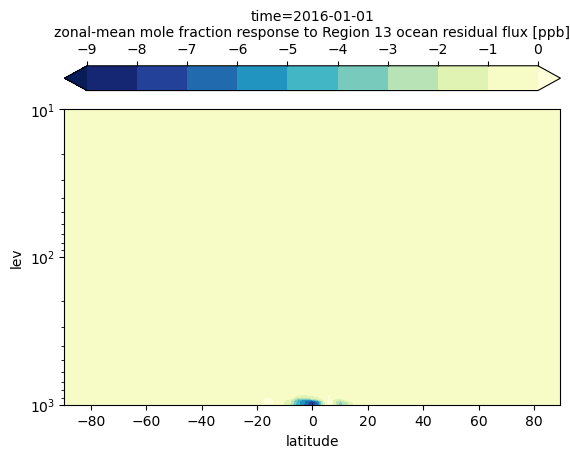

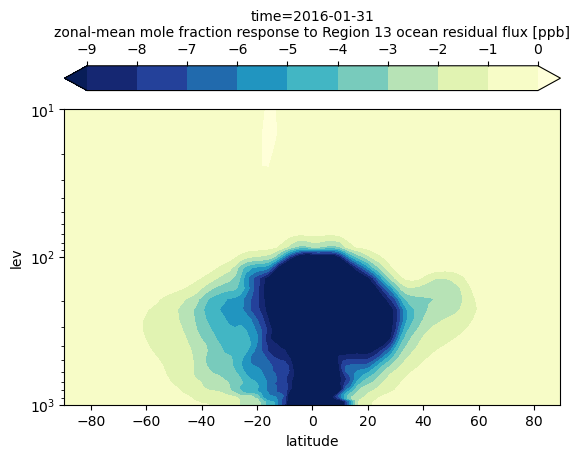

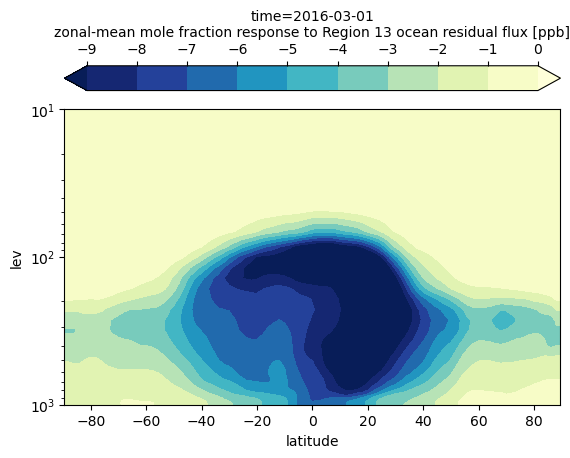

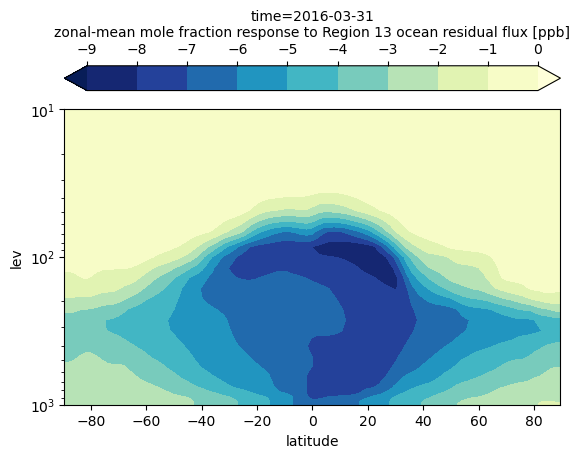

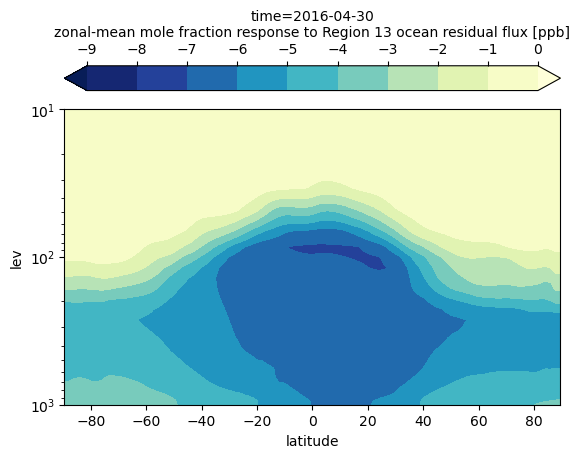

In [42]:
# lat-time at 100 hPa
for i in range(5):
    dd = dd14_slice.isel(time=30*i)
    levels = [-9, -8, -7, -6, -5, -4, -3, -2, -1, 0]
    fig = plt.figure()
    ax = fig.add_subplot()
    cf = ax.contourf(dd.lat, [inversion_tools.lev_to_p(pp) for pp in np.arange(len(dd.lev))+1], dd*1e3, levels=levels, extend='both', cmap='YlGnBu_r')
    #ax.contour(dd.lat, dd.time, dd*1e3, levels=levels, colors='k', linestyles='-', linewidths=0.2)
    ax.set_xlabel('latitude')
    ax.set_ylabel('lev')
    ax.set_yscale('log')
    ax.set_ylim([10, 1000])
    ax.invert_yaxis()
    cb = plt.colorbar(cf, location='top')
    cb.set_label(f'time={str(dd.time.values).split('T')[0]}\nzonal-mean mole fraction response to Region 13 ocean residual flux [ppb]')
    plt.savefig(f'zonalMean_{i}.png')

In [17]:
inversion_tools.lev_to_p(35)

100.514

In [38]:
inversion_tools.lev_to_p(1)

1005.65